In [4]:
import pandas as pd

In [53]:
df=pd.read_csv("/content/11) Powerplant dataset.csv")
df.head()

#AT => Temp
#V => Vaccum
#AP => Pressure
#RH => Humidity
#PE => Produced Eneregy (output)


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [13]:
x=df.drop("PE",axis=1);
y=df["PE"]


In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [55]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [56]:
import torch
import torch.nn as nn

x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [57]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)


In [58]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [ ]:
# CREATING ANN MODEL

In [59]:
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model=nn.Sequential(
        #1st Layer
        nn.Linear(x_train.shape[1],6),
        nn.ReLU(),

        #2nd Layer
        nn.Linear(6,6),
        nn.ReLU(),

        #3rd Layer
        nn.Linear(6,1)
    )
  def forward(self,x):
    return self.model(x)


In [60]:
# setting loss func and optimisers
import torch.optim as optim

model=ANN()

criterion=nn.MSELoss()
optimiser=optim.Adam(model.parameters())



In [ ]:
#Training the model


In [68]:
epochs =100
train_loss=[]
val_loss=[]
best_val_loss=float("inf")
for epoch in range(epochs):
  model.train() # goes in to training mode
  running_loss=0.0 #tot training loss for 1 epoch


  for xb,yb in train_loader:
    #xb features of batch 1
    #yb =labels of batch 1
    optimiser.zero_grad() #clearing gradients
    outputs=model(xb) # forward prop , predicted outputs for this batch
    loss=criterion(outputs,yb) # computing loss
    loss.backward() # backpropagation
    optimiser.step() # params update

    running_loss+=loss.item() # loss is a tensor => python float

  epoch_train_loss=running_loss/len(train_loader)
  train_loss.append(epoch_train_loss)
    #validation
    # model.eval() # goes in to evaluation mode
  running_val_loss=0.0
  with torch.no_grad():
    for xb,yb in test_loader:
      outputs=model(xb)
      loss=criterion(outputs,yb)
      running_val_loss+=loss.item()



    epoch_val_loss=running_val_loss/len(test_loader)
    val_loss.append(epoch_val_loss)

    print(f"Epoch ${epoch+1}/{epochs}==> training_loss: ${epoch_train_loss} & val_loss : ${epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
      best_val_loss=epoch_val_loss
      torch.save(model.state_dict(),"best_model.pt") # .pt ot .pth







Epoch $1/100==> training_loss: $21.43963187932968 & val_loss : $20.04791941642761
Epoch $2/100==> training_loss: $21.441574454307556 & val_loss : $19.760421546300254
Epoch $3/100==> training_loss: $21.514458334445955 & val_loss : $20.3912517229716
Epoch $4/100==> training_loss: $21.533682604630787 & val_loss : $20.107632223765055
Epoch $5/100==> training_loss: $21.438811163107555 & val_loss : $20.808658679326374
Epoch $6/100==> training_loss: $21.587283154328663 & val_loss : $19.620741637547813
Epoch $7/100==> training_loss: $21.357063674926756 & val_loss : $19.531303612391152
Epoch $8/100==> training_loss: $21.447886208693188 & val_loss : $19.58841414451599
Epoch $9/100==> training_loss: $21.499466808636985 & val_loss : $19.847349707285563
Epoch $10/100==> training_loss: $21.456180795033774 & val_loss : $19.80555418332418
Epoch $11/100==> training_loss: $21.36361189285914 & val_loss : $19.628694820404053
Epoch $12/100==> training_loss: $21.40172688563665 & val_loss : $20.0792247931162

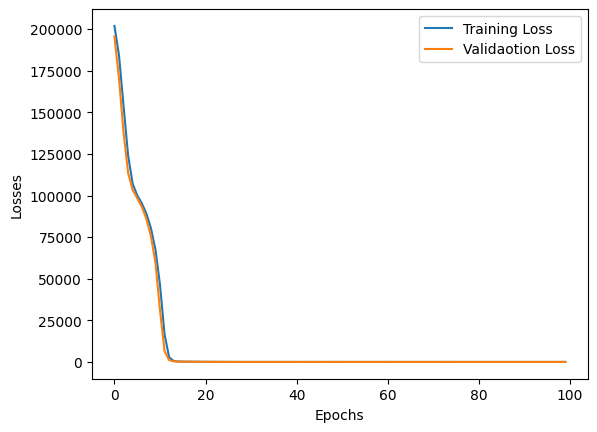

In [64]:
#lets visualise it
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({

    "train_loss":train_loss,
    "val_loss":val_loss
}
)

plt.plot(loss_df["train_loss"],label="Training Loss")
plt.plot(loss_df["val_loss"],label="Validaotion Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [69]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [71]:
#Evaluation
#train_MSE
#test_MSE
#R2_SCORE

model.eval()
with torch.no_grad():
  train_preds=model(x_train_tensor)
  test_preds=model(x_test_tensor)

  train_mse_loss=criterion(train_preds,y_train_tensor)
  test_mse_loss=criterion(test_preds,y_test_tensor)

print(f"Train MSE Loss:{train_mse_loss.item()}")
print(f"Test MSE Loss:{test_mse_loss.item()}")


Train MSE Loss:21.296716690063477
Test MSE Loss:19.52242088317871
